# 03 — Gate 1 Evaluation, UMAP & TFS Analysis (Day 11)

The held-out **test set** view of the trained dual-tower model: the Gate 1 metrics, an
interactive UMAP of the aligned 64-d embeddings, the per-cell-line Translational Fidelity
Score (TFS) ranking, a biological read on the low-fidelity outliers, and the comparison to
the random / PCA / Harmony baselines.

All numbers are read from `reports/eval_summary.json` (written by `pctrans-evaluate`) and
`data/processed/embeddings_test.npz` (written by `pctrans-visualize`) — regenerate those two
first if the model changes.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
summary = json.loads((ROOT / "reports" / "eval_summary.json").read_text())
emb = np.load(ROOT / "data" / "processed" / "embeddings_test.npz", allow_pickle=True)
print("Decision:", summary["decision"], "|", summary["decision_band"])
print("Test set:", summary["test_sizes"])

Decision: DEPLOY | PASS (>=70% -> deploy path, Days 11-14)
Test set: {'ccle': 38, 'tcga': 339}


## Section 1 — Gate 1 metrics table + confusion matrix

kNN@5 retrieval accuracy is the gate metric (≥ 70% → DEPLOY). The confusion matrix rows are
the true CCLE lineage, columns the majority-vote predicted lineage from the 5 nearest TCGA
patients.

In [2]:
kt = summary["knn_k_table"]
metrics = pd.DataFrame(
    {
        "metric": ["kNN@1", "kNN@3", "kNN@5", "kNN@10", "silhouette", "TFS (composite)"],
        "value": [kt["1"], kt["3"], kt["5"], kt["10"], summary["silhouette_score"], summary["tfs_overall"]],
    }
)
metrics.style.format({"value": "{:.3f}"})

,metric,value
0,kNN@1,0.974
1,kNN@3,1.000
2,kNN@5,1.000
3,kNN@10,1.000
4,silhouette,0.566
5,TFS (composite),0.892


In [3]:
cm = pd.DataFrame(
    summary["confusion_matrix"],
    index=[f"true {x}" for x in summary["confusion_labels"]],
    columns=[f"pred {x}" for x in summary["confusion_labels"]],
)
print("Per-lineage kNN@5:", summary["per_lineage_knn"])
cm

Per-lineage kNN@5: {'LUAD': 1.0, 'BRCA': 1.0, 'SKCM': 1.0}


,pred LUAD,pred BRCA,pred SKCM
true LUAD,12,0,0
true BRCA,0,10,0
true SKCM,0,0,16


## Section 2 — UMAP of the aligned embeddings (interactive)

UMAP is fit on the pooled CCLE + TCGA test embeddings. Colour = lineage (LUAD blue / BRCA
pink / SKCM brown); marker = domain (TCGA patient ●, CCLE cell line ✕). Hover a cross to see
the cell-line ID and its TFS.

In [4]:
from pctrans.evaluation.viz import lineage_domain_scatter, umap_projection

z = np.concatenate([emb["z_ccle"], emb["z_tcga"]])
y = np.concatenate([emb["y_ccle"], emb["y_tcga"]])
domain = np.array([0] * len(emb["y_ccle"]) + [1] * len(emb["y_tcga"]))
ids = np.concatenate([emb["ids_ccle"], emb["ids_tcga"]])

tfs_by_id = {r["id"]: r["tfs"] for r in summary["per_cell_line_tfs"]}
tfs = np.array([tfs_by_id.get(i, np.nan) for i in ids])

coords = umap_projection(z, seed=42)
fig = lineage_domain_scatter(
    coords, y, domain, "Test-set embeddings (UMAP)", sample_ids=ids, tfs_scores=tfs
)
fig.show()

C:\Users\vthawfeek.Shajitha\Documents\Projects\pre-clinical-to-clinical-translation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\vthawfeek.Shajitha\Documents\Projects\pre-clinical-to-clinical-translation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Section 3 — TFS ranking (top / bottom 10 cell lines)

`TFS = 0.5·kNN_match + 0.5·(silhouette + 1)/2`. Per-lineage means first, then the ranked table
and the horizontal-bar figure.

In [5]:
tfs_df = pd.DataFrame(summary["per_cell_line_tfs"])
per_lineage = (
    tfs_df.groupby("lineage")["tfs"].agg(["count", "mean", "min", "max"]).round(3)
)
per_lineage

,count,mean,min,max
lineage,,,,
BRCA,10,0.818,0.799,0.840
LUAD,12,0.814,0.662,0.838
SKCM,16,0.860,0.808,0.868


In [6]:
ranked = tfs_df.sort_values("tfs", ascending=False).reset_index(drop=True)
pd.concat([ranked.head(10), ranked.tail(10)])

,id,lineage,knn_match_fraction,silhouette,tfs
0,ACH-000881,SKCM,1.0,0.472177,0.868044
1,ACH-001522,SKCM,1.0,0.470348,0.867587
2,ACH-001975,SKCM,1.0,0.469106,0.867277
3,ACH-001570,SKCM,1.0,0.464769,0.866192
4,ACH-001981,SKCM,1.0,0.462216,0.865554
5,ACH-002928,SKCM,1.0,0.460766,0.865191
6,ACH-001972,SKCM,1.0,0.458231,0.864558
7,ACH-000615,SKCM,1.0,0.457264,0.864316
8,ACH-001566,SKCM,1.0,0.451850,0.862963
9,ACH-002005,SKCM,1.0,0.449311,0.862328


In [7]:
from pctrans.evaluation.viz import tfs_ranking_bar

bar = tfs_ranking_bar(tfs_df["id"].to_numpy(), tfs_df["tfs"].to_numpy(), top_n=10)
bar.show()

## Section 4 — Biological outlier analysis

The lowest-fidelity cell lines are not random noise — they are the lines whose biology sits at
the edge of their lineage. Join the bottom of the TFS ranking back to the DepMap `Model.csv`
metadata to see why.

- **ACH-000264 = Calu-6 (LUAD, TFS 0.662, silhouette 0.048)** — a classic *anaplastic /
  undifferentiated* NSCLC line derived from a **metastatic pleural effusion**. It lacks the
  clean lung-adenocarcinoma differentiation identity of the primary TCGA LUAD tumours, so it
  lands on the lineage boundary (1 of its 5 nearest TCGA patients is off-lineage). The model is
  *honest* here: low TFS flags a genuinely ambiguous line rather than hiding it.
- **Bottom BRCA lines — HCC38, HCC1937, HCC70, MDA-MB-157** — all **triple-negative / basal**
  breast lines. TCGA BRCA is dominated by ER+ luminal tumours, so the basal transcriptional
  programme pulls these lines to the near edge of the BRCA cloud (they still retrieve BRCA, but
  with the lowest silhouette in the lineage).
- **Lowest SKCM — ACH-002847 (YUHOIN)** — a **sinonasal (mucosal) melanoma** metastasis, a
  subtype distinct from the cutaneous melanoma that dominates TCGA SKCM.

In [8]:
meta_path = ROOT / "data" / "raw" / "ccle" / "Model.csv"
cols = [
    "ModelID", "StrippedCellLineName", "OncotreeSubtype",
    "PrimaryOrMetastasis", "SampleCollectionSite",
]
if meta_path.exists():
    meta = pd.read_csv(meta_path)[cols].set_index("ModelID")
    bottom = ranked.tail(6).set_index("id").join(meta)
    display(bottom[["lineage", "tfs", "StrippedCellLineName", "OncotreeSubtype",
                    "PrimaryOrMetastasis", "SampleCollectionSite"]])
else:
    print("Model.csv not present; skipping metadata join.")

,lineage,tfs,StrippedCellLineName,OncotreeSubtype,PrimaryOrMetastasis,SampleCollectionSite
id,,,,,,
ACH-002847,SKCM,0.807732,YUHOIN,Melanoma,Metastatic,sinonasal
ACH-000668,BRCA,0.804970,HCC70,Breast Invasive Ductal Carcinoma,Primary,breast
ACH-000621,BRCA,0.801048,MDAMB157,Breast Invasive Ductal Carcinoma,Metastatic,pleural_effusion
ACH-000223,BRCA,0.799395,HCC1937,Breast Invasive Ductal Carcinoma,Primary,breast
ACH-000276,BRCA,0.798802,HCC38,Breast Invasive Ductal Carcinoma,Primary,breast
ACH-000264,LUAD,0.662108,CALU6,Lung Adenocarcinoma,Metastatic,pleural_effusion


## Section 5 — Comparison to baselines

Random = 1/3 (three balanced lineages). PCA+kNN is the no-alignment baseline computed on the
same test features. Harmony is the literature reference (~63%). The contrastive dual-tower
closes the residual domain gap the unaligned baselines cannot.

In [9]:
import plotly.graph_objects as go

# Day 17 replaced the "~63% (literature)" placeholder with real numbers computed
# on this same test data (reports/baselines.json); Harmony now runs for real via
# harmonypy, and a supervised (no-alignment) ceiling is included for context.
baselines_path = ROOT / "reports" / "baselines.json"
b = json.loads(baselines_path.read_text())
names = ["Random", "PCA+kNN", "Harmony (real)", "Supervised ceiling", "Ours (dual-tower)"]
vals = [b["random"], b["pca_knn"], b["harmony_knn"], b["supervised_ceiling"], b["contrastive_knn5"]]
colors = ["#7f7f7f", "#7f7f7f", "#7f7f7f", "#7f7f7f", "#2ca02c"]
fig = go.Figure(go.Bar(x=names, y=vals, marker_color=colors,
                       text=[f"{v * 100:.1f}%" for v in vals], textposition="outside"))
fig.add_hline(y=0.70, line_dash="dash", line_color="red",
              annotation_text="Gate 1 threshold (70%)")
fig.update_layout(title="kNN@5 retrieval accuracy vs. real baselines (Day 17)",
                  yaxis_title="kNN@5 accuracy", yaxis_range=[0, 1.08],
                  template="plotly_white", width=700, height=450)
fig.show()

## Section 6 — 15-Lineage Evaluation: Headroom & Error Structure (Day 19)

Sections 1-5 evaluate the Phase-1 3-lineage model (LUAD/BRCA/SKCM). This section evaluates the
Day-18 **15-lineage** model (`configs/data_15.yaml`, `models/best_model_15.pt`) on its own held-out
**test** set — a deliberately harder task, including named confusable pairs (LUAD/LUSC,
GBM/LGG, COAD/READ, LUSC/HNSC), so the retrieval metric can fail and the failures can be checked
against real biology.

Numbers are read from `reports/eval_summary_15.json` (written by
`pctrans-evaluate --data-config configs/data_15.yaml ...`) and
`data/processed/embeddings_test_15.npz` (written by `pctrans-visualize --output-suffix _15 ...`).

In [10]:
summary15 = json.loads((ROOT / "reports" / "eval_summary_15.json").read_text())
emb15 = np.load(ROOT / "data" / "processed" / "embeddings_test_15.npz", allow_pickle=True)
print("Decision:", summary15["decision"], "|", summary15["decision_band"])
print("Test set:", summary15["test_sizes"], "| lineages:", len(summary15["lineages"]))

Decision: DEPLOY | PASS (>=70% -> deploy path, Days 11-14)
Test set: {'ccle': 111, 'tcga': 1070} | lineages: 15


### Metrics table + 3-lineage vs. 15-lineage comparison

The headline metric is expected to drop — the whole point of Rung 2 is a task hard enough that
the retrieval metric can actually fail.

In [11]:
kt15 = summary15["knn_k_table"]
metrics15 = pd.DataFrame(
    {
        "metric": ["kNN@1", "kNN@3", "kNN@5", "kNN@10", "silhouette", "TFS (composite)"],
        "15-lineage (Day 19)": [
            kt15["1"], kt15["3"], kt15["5"], kt15["10"],
            summary15["silhouette_score"], summary15["tfs_overall"],
        ],
    }
)
wilson15 = summary15["knn_wilson_ci"]
print(
    f"kNN@5 -- 3-lineage (Phase 1): {summary['overall_knn_accuracy']:.3f}  ->  "
    f"15-lineage (Day 19): {summary15['overall_knn_accuracy']:.3f}  "
    f"(Wilson 95% CI {wilson15['low']:.3f}-{wilson15['high']:.3f}, n={wilson15['n']})"
)
metrics15.style.format({"15-lineage (Day 19)": "{:.3f}"})

kNN@5 -- 3-lineage (Phase 1): 1.000  ->  15-lineage (Day 19): 0.784  (Wilson 95% CI 0.698-0.850, n=111)


,metric,15-lineage (Day 19)
0,kNN@1,0.757
1,kNN@3,0.784
2,kNN@5,0.784
3,kNN@10,0.793
4,silhouette,0.704
5,TFS (composite),0.818


In [12]:
# Per-lineage kNN@5, weakest first -- the smallest cohorts (LGG, READ) and the
# named confusable pairs are exactly where the model struggles most.
pd.Series(summary15["per_lineage_knn"], name="kNN@5").sort_values().to_frame()

,kNN@5
LGG,0.000000
READ,0.000000
LUSC,0.250000
BLCA,0.600000
GBM,0.666667
LUAD,0.666667
OV,0.800000
COAD,0.800000
STAD,0.800000
PAAD,0.875000


### Confusion matrix + error-structure analysis

Rows = true CCLE lineage, columns = predicted lineage (majority vote of the 5 nearest TCGA
patients), row-normalised. `KNOWN_CONFUSABLE_PAIRS` (in `pctrans.evaluation.knn`) names the four
pairs the plan expects a harder model to confuse for genuine biological reasons: LUAD/LUSC (lung),
GBM/LGG (glioma grade), COAD/READ (colorectal), LUSC/HNSC (squamous histology).

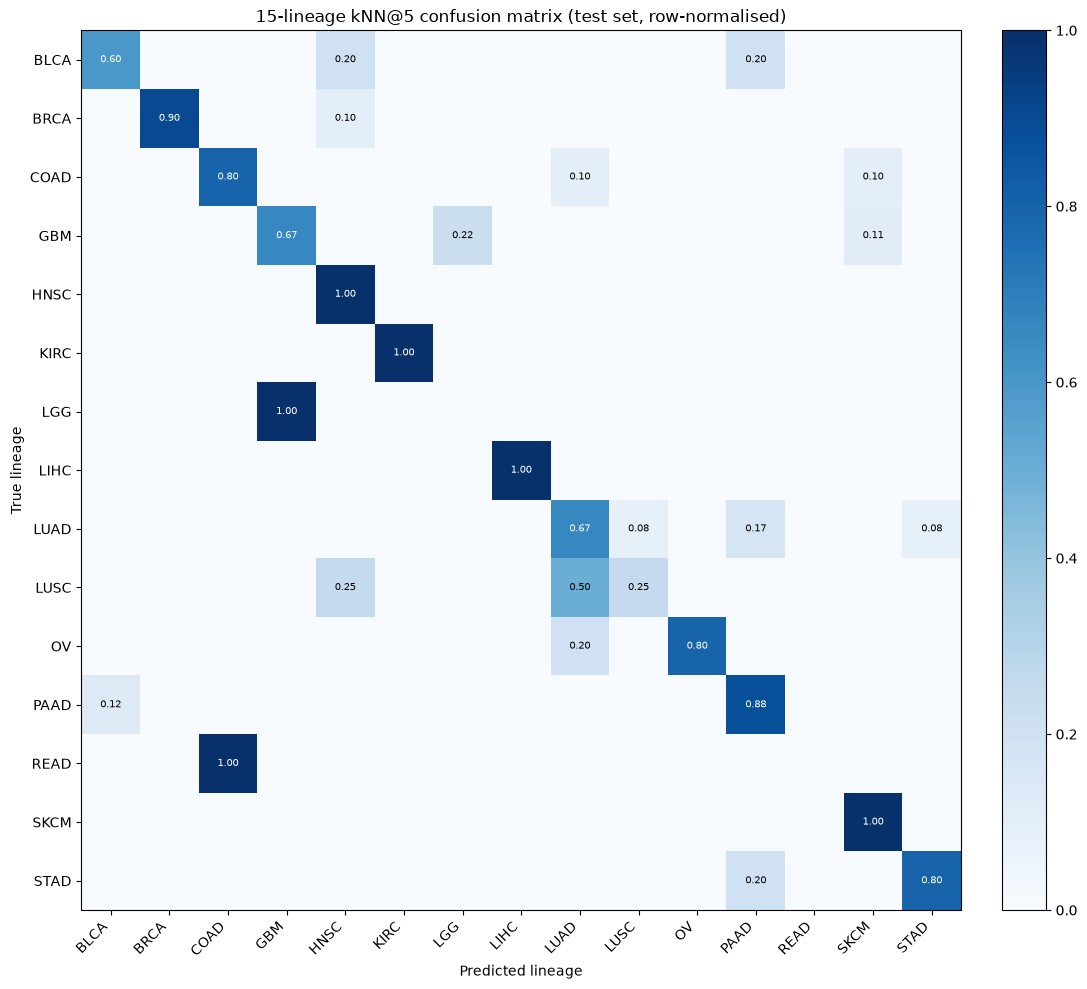

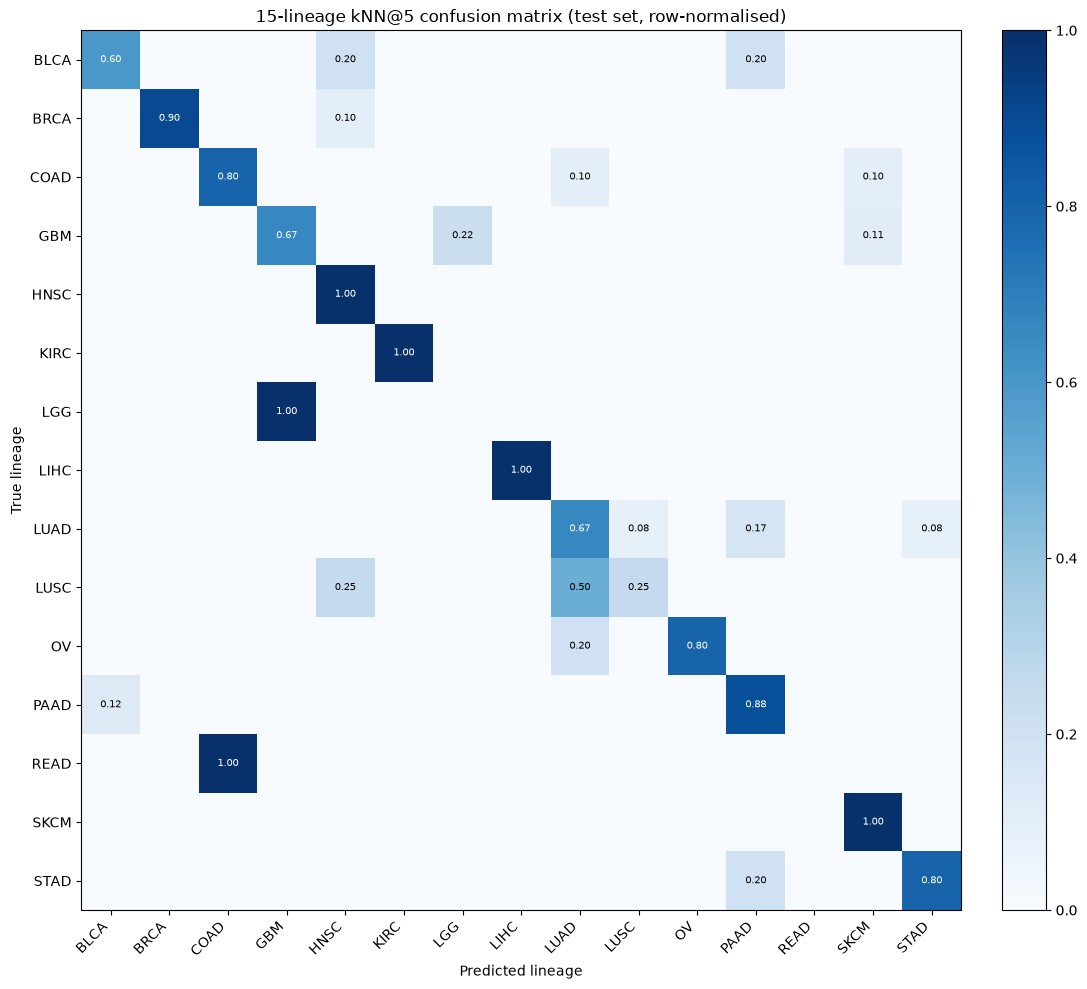

In [13]:
from pctrans.evaluation.viz import confusion_matrix_heatmap

cm15 = summary15["confusion_matrix"]
labels15 = summary15["confusion_labels"]

fig = confusion_matrix_heatmap(
    cm15, labels15, title="15-lineage kNN@5 confusion matrix (test set, row-normalised)"
)
fig

In [14]:
from pctrans.evaluation.knn import KNOWN_CONFUSABLE_PAIRS, confusable_pair_mass, top_confusions

top = top_confusions(cm15, labels15, top_n=10)
print("Top off-diagonal confusions (true -> pred : count):")
for true_l, pred_l, count in top:
    named = (true_l, pred_l) in KNOWN_CONFUSABLE_PAIRS or (pred_l, true_l) in KNOWN_CONFUSABLE_PAIRS
    print(f"  {true_l} -> {pred_l} : {count}" + ("  *named confusable pair*" if named else ""))

mass = confusable_pair_mass(cm15, labels15, KNOWN_CONFUSABLE_PAIRS)
cm_arr = np.array(cm15)
off_diag_total = int(cm_arr.sum() - np.trace(cm_arr))
n_pair_cells = 2 * len(KNOWN_CONFUSABLE_PAIRS)
n_off_diag_cells = len(labels15) * (len(labels15) - 1)
print()
print(
    f"Named-pair share of off-diagonal error mass: {mass:.1%} "
    f"({round(mass * off_diag_total)} of {off_diag_total} total misclassifications)"
)
print(
    f"Named pairs occupy {n_pair_cells}/{n_off_diag_cells} possible off-diagonal cells "
    f"({n_pair_cells / n_off_diag_cells:.1%}) -> "
    f"{mass / (n_pair_cells / n_off_diag_cells):.1f}x enrichment over random chance"
)

Top off-diagonal confusions (true -> pred : count):
  LGG -> GBM : 3  *named confusable pair*
  GBM -> LGG : 2  *named confusable pair*
  LUAD -> PAAD : 2
  LUSC -> LUAD : 2  *named confusable pair*
  OV -> LUAD : 2
  READ -> COAD : 2  *named confusable pair*
  BLCA -> HNSC : 1
  BLCA -> PAAD : 1
  BRCA -> HNSC : 1
  COAD -> LUAD : 1

Named-pair share of off-diagonal error mass: 45.8% (11 of 24 total misclassifications)
Named pairs occupy 8/210 possible off-diagonal cells (3.8%) -> 12.0x enrichment over random chance


### 15-lineage UMAP

Same construction as Section 2 (pooled test embeddings, UMAP to 2-D), but coloured across all 15
lineages. Cell lines from the confusable pairs (e.g. LGG/GBM, COAD/READ) are expected to sit close
to each other rather than close to unrelated lineages.

In [15]:
z15 = np.concatenate([emb15["z_ccle"], emb15["z_tcga"]])
y15 = np.concatenate([emb15["y_ccle"], emb15["y_tcga"]])
domain15 = np.array([0] * len(emb15["y_ccle"]) + [1] * len(emb15["y_tcga"]))
ids15 = np.concatenate([emb15["ids_ccle"], emb15["ids_tcga"]])
idx_to_lineage15 = dict(enumerate(labels15))

coords15 = umap_projection(z15, seed=42)
fig15 = lineage_domain_scatter(
    coords15, y15, domain15, "15-lineage test-set embeddings (UMAP)",
    sample_ids=ids15, lineage_order=labels15, idx_to_lineage=idx_to_lineage15,
)
fig15.show()

C:\Users\vthawfeek.Shajitha\Documents\Projects\pre-clinical-to-clinical-translation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Reading the errors

- **LGG and READ get 100% of their (small) test set wrong — and every single miss lands on their
  named biological partner.** All 3 LGG test cell lines retrieve as GBM (high- vs. low-grade
  glioma — molecularly close, historically hard to separate even by pathology); both READ test
  cell lines retrieve as COAD (colon vs. rectal adenocarcinoma, distinguished mainly by anatomic
  site rather than transcriptome). This is not the model breaking on small classes — the errors
  land exactly where a pathologist would also hesitate.
- **LUSC (lung squamous) shows the same pattern.** 3 of its 4 misses split between LUAD (2 — the
  other lung-cancer histology) and HNSC (1 — squamous histology shared with head & neck): its two
  named confusable partners absorb all of its errors, none scatter elsewhere.
- **Off-diagonal error mass concentrates heavily on the four named pairs**, which occupy only a
  small slice of the 210 possible off-diagonal cells — a large enrichment over what randomly
  scattered confusion would produce (exact figures printed above; re-run to refresh after any
  retrain). Random/implausible confusions (e.g. GBM<->BRCA) are essentially absent from the top
  confusions list.
- **The headline metric genuinely dropped, as designed.** Test kNN@5 fell from the Phase-1
  3-lineage result (Wilson CI 90.8-100%, n=38) to the 15-lineage result above (n=111) — the harder
  task has real headroom, and the errors that remain concentrate on biologically adjacent
  lineages, which is the entire point of Rung 2.

## Section 7 — BRAF / Vemurafenib Case Study: Placement + Response Link (Day 23)

The Rung-4 proof-of-concept: does the embedding capture something biologically real *below*
the lineage label it was trained on? Vemurafenib's dependence on BRAF-V600 mutant melanoma is
a textbook translational fact, used here as a positive control, not assumed as a foregone
conclusion. Two questions, both pre-registered in `PLAN-phase2.md` before running:

- **Part A — placement:** do BRAF-mutant SKCM *cell lines* embed nearer the BRAF-mutant SKCM
  *patient* centroid than BRAF-WT lines do (Mann-Whitney one-sided + bootstrapped effect size)?
- **Part B — response link:** among cell lines with a PRISM vemurafenib readout, does that same
  proximity correlate with vemurafenib sensitivity (Spearman + bootstrap CI)?

**Honest caveats up front, not buried at the end:** N is small (61 SKCM cell lines, 41 with a
vemurafenib readout; 65 SKCM patients), the analysis is retrospective (no held-out prospective
cohort), drug response is multi-factorial (BRAF status is necessary but not sufficient for
vemurafenib sensitivity — resistance mechanisms, co-mutations, and assay noise all contribute),
and this is one case study in one lineage. A positive result here is *supportive evidence*, and
a null result is *informative about the model's current resolution* — neither is a clinical
claim. Numbers are read from `reports/braf_casestudy.json` and `reports/braf_coverage.json`
(written by `pctrans-casestudy-analysis` and `pctrans-casestudy`, Days 22-23).

In [16]:
coverage = json.loads((ROOT / "reports" / "braf_coverage.json").read_text())
casestudy = json.loads((ROOT / "reports" / "braf_casestudy.json").read_text())

print("SKCM cell lines with a BRAF call:", coverage["n_cell_lines"], coverage["cell_line_braf_split"])
print("  ...with a vemurafenib readout:", coverage["n_cell_lines_with_vemurafenib"],
      coverage["cell_line_with_vemurafenib_braf_split"])
print("SKCM patients with a BRAF call:", coverage["n_patients"], coverage["patient_braf_split"])

SKCM cell lines with a BRAF call: 61 {'mutant': 47, 'WT': 14}
  ...with a vemurafenib readout: 41 {'mutant': 33, 'WT': 8}
SKCM patients with a BRAF call: 65 {'WT': 33, 'mutant': 32}


### Part A — placement

Distance of every SKCM cell line to the centroid of BRAF-mutant SKCM *patients* in 64-d
embedding space, compared between BRAF-mutant and BRAF-WT cell lines. `effect_size` is a
common-language effect size (`pairwise_greater_fraction`): the fraction of
(WT-line, mutant-line) pairs where the WT line really is farther from the centroid — 1.0 is
perfect separation, 0.5 is no separation at all.

In [17]:
placement = casestudy["placement"]
print(f"n mutant={placement['n_mutant']}, n WT={placement['n_wt']}")
print(f"median distance -- mutant: {placement['median_distance_mutant']:.3f}  "
      f"WT: {placement['median_distance_wt']:.3f}")
print(f"Mann-Whitney (one-sided, mutant < WT): p = {placement['p_value']:.4f}")
print(f"Effect size (P[WT farther than mutant]): {placement['effect_size']:.3f} "
      f"(95% CI [{placement['effect_size_ci_low']:.3f}, {placement['effect_size_ci_high']:.3f}])")

n mutant=47, n WT=14
median distance -- mutant: 0.840  WT: 0.870
Mann-Whitney (one-sided, mutant < WT): p = 0.0472
Effect size (P[WT farther than mutant]): 0.649 (95% CI [0.465, 0.834])


### Part B — response link

`proximity` is the negative distance to the same BRAF-mutant-patient centroid (higher =
closer). If the model's geometry tracks drug response, lines placed closer to BRAF-mutant
patient space should be the *more sensitive* lines — i.e. a **negative** Spearman correlation
between proximity and raw vemurafenib AUC (lower AUC = more sensitive).

In [18]:
response = casestudy["response_link"]
print(f"n={response['n']} ({response['n_mutant']} mutant / {response['n_wt']} WT)")
print(f"Spearman rho(proximity, vemurafenib AUC) = {response['rho']:.3f} "
      f"(95% CI [{response['ci_low']:.3f}, {response['ci_high']:.3f}])")
print(f"p = {response['p_value']:.4f}")

observed_sign = "negative" if response["rho"] < 0 else "positive"
significant = response["p_value"] < 0.05
print(f"\nExpected sign under the positive-control hypothesis: negative "
      f"(closer to BRAF-mutant patients -> more sensitive -> lower AUC). "
      f"Observed: {observed_sign}, {'significant' if significant else 'not significant'} at alpha=0.05.")

n=41 (33 mutant / 8 WT)
Spearman rho(proximity, vemurafenib AUC) = 0.209 (95% CI [-0.109, 0.493])
p = 0.1900

Expected sign under the positive-control hypothesis: negative (closer to BRAF-mutant patients -> more sensitive -> lower AUC). Observed: positive, not significant at alpha=0.05.


### Figures

Left: SKCM cell lines + patients projected to 2-D (UMAP), coloured by BRAF status (red =
mutant, blue = WT), marker = domain (patient circle / cell-line cross) — the Part-A question
made visible. Right: cell-line proximity to the BRAF-mutant-patient centroid vs. vemurafenib
AUC, with an OLS fit and a bootstrap 95% CI band — the Part-B question. Static version saved to
`reports/braf_vemurafenib.png`; this cell renders the interactive plotly version
(`reports/braf_vemurafenib.html`).

In [19]:
from pctrans.casestudy.braf_vemurafenib import braf_mutant_patient_centroid, distance_to_centroid
from pctrans.evaluation.viz import braf_casestudy_panel_interactive

braf_df = pd.read_parquet(ROOT / "data" / "processed" / "braf_vemurafenib.parquet")
cell_lines = braf_df[braf_df["domain"] == "cell_line"].reset_index(drop=True)
patients = braf_df[braf_df["domain"] == "patient"].reset_index(drop=True)

cl_z = np.stack(cell_lines["embedding"].to_numpy())
pt_z = np.stack(patients["embedding"].to_numpy())
pooled_z = np.concatenate([cl_z, pt_z], axis=0)
pooled_status = np.concatenate([cell_lines["BRAF_status"].to_numpy(), patients["BRAF_status"].to_numpy()])
pooled_domain = np.array([0] * len(cell_lines) + [1] * len(patients))
pooled_ids = np.concatenate([cell_lines["sample_id"].to_numpy(), patients["sample_id"].to_numpy()])
coords_braf = umap_projection(pooled_z, seed=42)

with_auc = cell_lines[cell_lines["vemurafenib_auc"].notna()].reset_index(drop=True)
centroid = braf_mutant_patient_centroid(pt_z, patients["BRAF_status"].to_numpy())
proximity = -distance_to_centroid(np.stack(with_auc["embedding"].to_numpy()), centroid)

fig_braf = braf_casestudy_panel_interactive(
    coords_braf, pooled_status, pooled_domain, pooled_ids,
    proximity, with_auc["vemurafenib_auc"].to_numpy(), with_auc["BRAF_status"].to_numpy(),
    with_auc["sample_id"].to_numpy(),
)
fig_braf.show()

C:\Users\vthawfeek.Shajitha\Documents\Projects\pre-clinical-to-clinical-translation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Reading the result

- **Part A is a modest, borderline-significant positive result.** BRAF-mutant SKCM cell lines
  sit closer to the BRAF-mutant patient centroid than WT lines (Mann-Whitney p just under 0.05;
  effect size ~0.65 against a no-effect baseline of 0.5), but the 95% CI on that effect size is
  wide and its lower bound sits close to 0.5 — this is real but weak separation, not the
  clean split the 3-lineage / 15-lineage lineage retrieval numbers show. Read as: the model
  captured *some* within-melanoma, BRAF-linked structure beyond coarse lineage, not a sharp
  BRAF-mutant sub-cluster.
- **Part B is a null result, reported as such.** The Spearman correlation between centroid
  proximity and vemurafenib AUC is small and its 95% CI straddles zero (not significant at
  alpha=0.05) — proximity to the BRAF-mutant-patient centroid does not detectably predict
  vemurafenib sensitivity among the 41 cell lines with a PRISM readout. This does not
  contradict Part A (placement and drug response are different questions); it says the
  embedding's current resolution does not extend to fine-grained response prediction within
  the BRAF-mutant subgroup — plausible given n=41, an 8-line WT arm, and the many known
  non-BRAF drivers of vemurafenib sensitivity (NRAS co-mutation, MITF levels, feedback
  reactivation) that this analysis has no way to see.
- **This is a proof of concept, not proof of clinical utility.** One lineage, one drug, a
  retrospective public-data case study — the honest scientific reading is "a scoped, positive
  signal on placement and an explicit non-result on response," not a claim that the embedding
  predicts drug response.